# Ridge Classification Model

## Importing all train/test pickle files as well as cleaned data

In [1]:
import pickle as pk

df_cleaned = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\df_cleaned.pkl", 'rb') as file:
    df_cleaned = pk.load(file)

In [2]:
df_cleaned.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,159.93
1,50002,1,3,Phone,1,8,Electronic Payment,Male,3,4,Mobile Phone,3,Single,7,1,15,0,1,0,120.90
2,50003,1,3,Phone,1,30,Debit Card,Male,2,4,Mobile Phone,3,Single,6,1,14,0,1,3,120.28
3,50004,1,0,Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134.07
4,50005,1,0,Phone,1,12,Credit Card,Male,3,3,Mobile Phone,5,Single,3,0,11,1,1,3,129.60


In [3]:
X_train = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\X_train.pkl", 'rb') as file:
    X_train = pk.load(file)

In [4]:
X_train.head()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_Electronic Payment,Gender_Male,PreferredOrderCat_Grocery,PreferredOrderCat_Laptop & Accessory,PreferredOrderCat_Mobile Phone,PreferredOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
2901,4,1,7,3,5,3,3,0,23,3,...,0,1,0,1,0,0,0,0,0,1
1450,30,2,8,2,4,1,10,0,21,0,...,0,0,1,0,0,0,0,1,1,0
2437,3,1,34,3,3,1,5,0,20,1,...,0,0,0,1,0,0,1,0,1,0
4027,2,3,10,4,4,4,3,0,20,2,...,1,0,0,0,0,0,1,0,1,0
362,0,1,6,3,4,4,2,0,13,1,...,0,1,0,0,0,0,1,0,0,1


In [5]:
X_test = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\X_test.pkl", 'rb') as file:
    X_test = pk.load(file)

In [6]:
X_test.head()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,...,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_Electronic Payment,Gender_Male,PreferredOrderCat_Grocery,PreferredOrderCat_Laptop & Accessory,PreferredOrderCat_Mobile Phone,PreferredOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
1907,0,1,6,3,3,1,2,1,13,6,...,0,0,1,1,0,0,1,0,0,1
1422,18,1,12,2,3,5,5,1,14,1,...,0,0,1,1,0,0,0,0,1,0
3435,29,1,25,4,4,4,5,1,15,7,...,1,0,0,1,0,1,0,0,0,0
5601,30,1,8,3,4,3,3,0,22,1,...,0,1,0,1,0,1,0,0,1,0
2708,6,3,16,2,3,3,2,0,14,0,...,0,0,1,1,0,1,0,0,0,1


In [7]:
y_train = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\y_train.pkl", 'rb') as file:
    y_train = pk.load(file)

In [8]:
y_train.head()

2901    0
1450    0
2437    0
4027    0
362     0
Name: Churn, dtype: int64

In [9]:
y_test = ''
with open(r"C:\Users\cover\Desktop\MISY331\Final Project\y_test.pkl", 'rb') as file:
    y_test = pk.load(file)

In [10]:
y_test.head()

1907    1
1422    0
3435    0
5601    0
2708    0
Name: Churn, dtype: int64

## Building the Model

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

rs = 1234

In [12]:
# Scale numeric features
scaler = StandardScaler()

# Scale training data only
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)



In [13]:
# Tune RidgeClassifier using GridSearchCV
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(
    estimator=RidgeClassifier(class_weight='balanced', random_state=rs),
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=5
)

ridge_grid.fit(X_train_scaled, y_train)

# Best model
ridge_model = ridge_grid.best_estimator_
print("Best alpha:", ridge_grid.best_params_['alpha'])


Best alpha: 0.01


In [14]:
# Fit the final Model
ridge_model.fit(X_train_scaled, y_train)


,alpha,0.01
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,'balanced'
,solver,'auto'
,positive,False
,random_state,1234


In [15]:
# Predict on training and test data
y_train_pred = ridge_model.predict(X_train_scaled)
y_test_pred = ridge_model.predict(X_test_scaled)


In [16]:
# Evaluate model performance
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Train Accuracy: 0.810371689294458
Test Accuracy: 0.7704626334519573

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.76      0.85       935
           1       0.41      0.81      0.54       189

    accuracy                           0.77      1124
   macro avg       0.68      0.79      0.70      1124
weighted avg       0.86      0.77      0.80      1124



In [17]:
# Permutation Feature Importance

# Compute permutation importance on test set
perm_importance = permutation_importance(
    ridge_model, X_test_scaled, y_test, 
    n_repeats=10, random_state=rs, scoring='accuracy'
)

# Create a dataframe of feature importances
feature_imp = pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

# Show top 10 features
print("Top 10 Features:")
print(feature_imp.head(10))



Top 10 Features:
                                 Feature  Importance
0                                 Tenure    0.071619
19  PreferredOrderCat_Laptop & Accessory    0.037900
20        PreferredOrderCat_Mobile Phone    0.024110
7                               Complain    0.023488
6                        NumberOfAddress    0.018772
21              PreferredOrderCat_Others    0.014413
15       PreferredPaymentMode_Debit Card    0.008986
1                               CityTier    0.008719
12                        CashbackAmount    0.008541
10                            OrderCount    0.006673


## Visuals

### Feature Importance Bar Chart

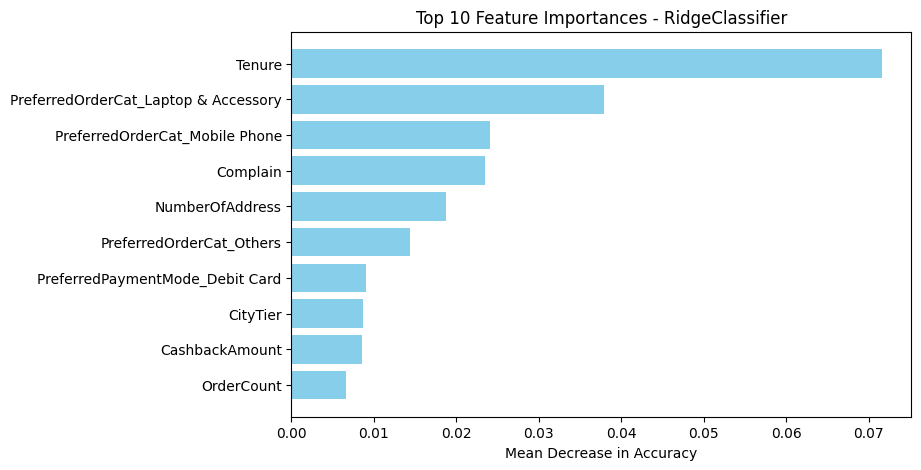

In [18]:
# Bar Chart for Feature Importance
top_features = feature_imp.head(10)
plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1], color='skyblue')
plt.xlabel("Mean Decrease in Accuracy")
plt.title("Top 10 Feature Importances - RidgeClassifier")
plt.show()

### Confusion Matrix

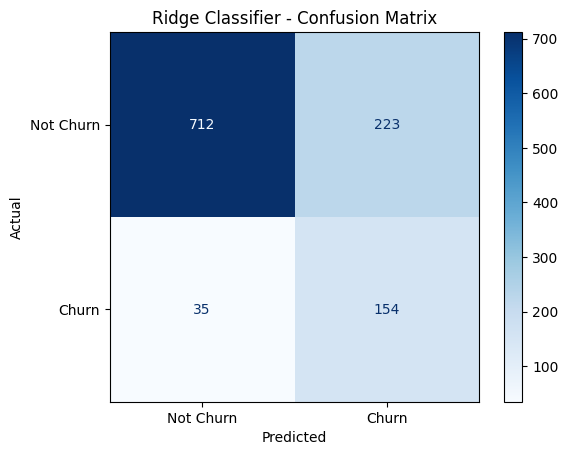

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churn', 'Churn'])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Analysis

### Model Performance

Accuracy: 0.77

Class = 0 (Non-Churn)
- Recall = 0.76
- The model is good at detecting customers who do not churn.
- Some non-churn customers are incorrectly predicted as churn, but overall performance for this class is solid.

Class = 1 (Churn)
- Recall = 0.81
- The model correctly identifies most customers who do churn.
- Class weighting and hyperparameter tuning help the model balance predictions between churn and non-churn customers.

### Interpretation

Overall Model Performance
- The tuned Ridge model reaches 77% test accuracy, with a train accuracy of 81%, indicating the model performs similarly on training and test data. This suggests the model is not overfitting.
- The model performs well for the majority class:
    - Non-churn recall = 0.76, meaning it correctly identifies most customers who stay.
- The model also performs well for the minority class:
    - Churn recall = 0.81, meaning it identifies most customers who actually churn.
- In practical terms, the model provides balanced predictions for both churn and non-churn customers, making it useful for churn-prevention strategies.
- Class weighting and hyperparameter tuning helped the model avoid bias toward the majority class, improving recall for churners.

### Feature Importance

Top Predictors of Churn:
- Tenure remains the strongest predictor; shorter-tenured customers are more likely to churn.
- PreferredOrderCat_Laptop & Accessory and PreferredOrderCat_Mobile Phone are also influential; customers favoring these categories are less likely to churn.
- Complain is highly influential; customers who file complaints are more likely to churn.
- CashbackAmount slightly reduces churn risk.

Other Influential Predictors:
- Features like NumberOfAddress, PreferredOrderCat_Others, PreferredPaymentMode_Debit Card, CityTier, and OrderCount have smaller but noticeable effects on churn.

Overall Interpretation:
- Churn is driven by a mix of loyalty (Tenure), customer behavior (Complaints, Ordering patterns), and incentives/payment behaviors (Cashback, category preferences, payment method).
- These features collectively help the model identify customers at higher risk of leaving versus those likely to stay.

In [20]:
import pickle

# Save the model
with open("3_Ridge.pkl", "wb") as file:
    pickle.dump('3_Ridge', file)